In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment
from scipy.stats import wilcoxon, ttest_rel


In [2]:
CSV_BEFORE = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_beforeREDSEA_gnn_predict.csv"
CSV_AFTER  = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_mesmer_afterREDSEA_gnn_predict.csv"

LABEL_BEFORE = "Mesmer_Before"
LABEL_AFTER  = "Mesmer_After"

CLUSTER = "leiden"
CTYPE   = "pred_name"
SLIDE   = "slide_name"
CELLID  = "CellID"
XCOL    = "x_centroid"
YCOL    = "y_centroid"


In [3]:
def load_minimal(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    req = [SLIDE, CELLID, CLUSTER, CTYPE]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} missing required columns: {missing}")

    keep = req.copy()
    for c in (XCOL, YCOL):
        if c in df.columns:
            keep.append(c)

    df = df[keep].dropna(subset=req).copy()
    for c in req:
        df[c] = df[c].astype(str)
    return df

before = load_minimal(CSV_BEFORE)
after  = load_minimal(CSV_AFTER)

print("Duplicate (slide, CellID) in BEFORE:", before.duplicated([SLIDE, CELLID]).sum())
print("Duplicate (slide, CellID) in AFTER :", after.duplicated([SLIDE, CELLID]).sum())

merged = before.merge(after, on=[SLIDE, CELLID], how="inner", suffixes=("_before", "_after"))

print("\nBEFORE cells:", len(before))
print("AFTER  cells:", len(after))
print("Matched cells (inner join):", len(merged))
print("Match rate BEFORE:", len(merged) / max(1, len(before)))
print("Match rate AFTER :", len(merged) / max(1, len(after)))

Duplicate (slide, CellID) in BEFORE: 0
Duplicate (slide, CellID) in AFTER : 0

BEFORE cells: 162439
AFTER  cells: 161867
Matched cells (inner join): 161656
Match rate BEFORE: 0.9951797290059653
Match rate AFTER : 0.9986964606745043



Overall weighted purity (matched cells only):
  Mesmer_Before = 0.6175
  Mesmer_After  = 0.6220
  Diff (After - Before) = 0.0045

Clusters BEFORE: 39 | Clusters AFTER: 36 | Cell types: 28

Matched clusters: 36


,cluster_before,cluster_after,cosine_similarity,n_cells_before,purity_before,top_celltype_before,n_cells_after,purity_after,top_celltype_after,delta_purity_after_minus_before
0,38,35,1.000000,271,0.996310,B,242,0.995868,B,-0.000442
1,32,31,0.999974,1046,0.966539,Paneth,1140,0.966667,Paneth,0.000127
2,18,25,0.999915,1092,0.873626,Neuroendocrine,1102,0.867514,Neuroendocrine,-0.006113
3,33,30,0.999913,2930,0.973379,Smooth muscle,2888,0.974377,Smooth muscle,0.000998
4,15,15,0.999868,4429,0.964778,Smooth muscle,7608,0.958070,Smooth muscle,-0.006707
5,31,34,0.999773,1900,0.628947,Epithelial,1855,0.642588,Epithelial,0.013640
6,19,11,0.999508,4902,0.815177,CD4+ T,5032,0.818362,CD4+ T,0.003185
7,30,26,0.999437,2010,0.955721,Smooth muscle,2240,0.904018,Smooth muscle,-0.051704
8,10,18,0.999397,3220,0.901242,Nerve,3394,0.941072,Nerve,0.039830
9,24,17,0.999065,1367,0.809071,PDPN+ Stromal,1630,0.752761,PDPN+ Stromal,-0.056310



Paired Wilcoxon signed-rank test on matched-cluster purity:
  statistic = 290.000
  p-value   = 5.0887e-01
  mean Δpurity (After − Before)   = -0.0191
  median Δpurity (After − Before) = -0.0012

Paired t-test on matched-cluster purity:
  t = -0.659
  p = 5.1411e-01


/tmp/ipykernel_353275/34547636.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


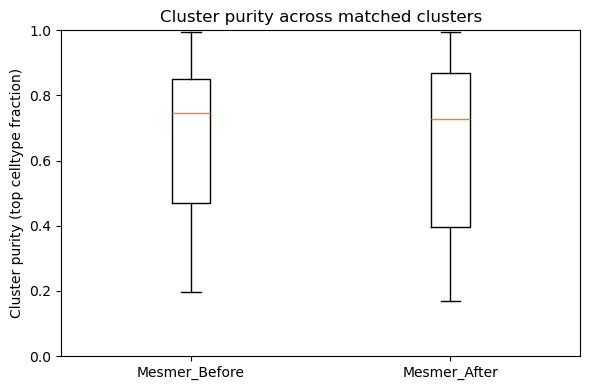

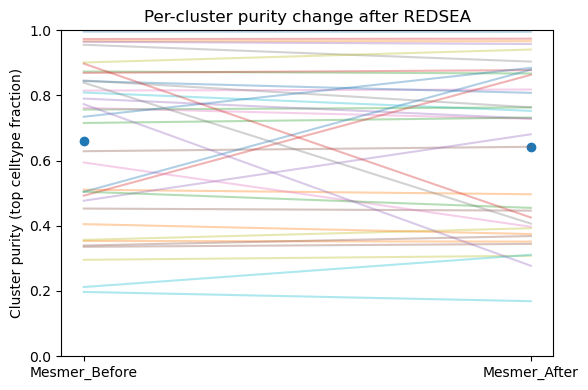

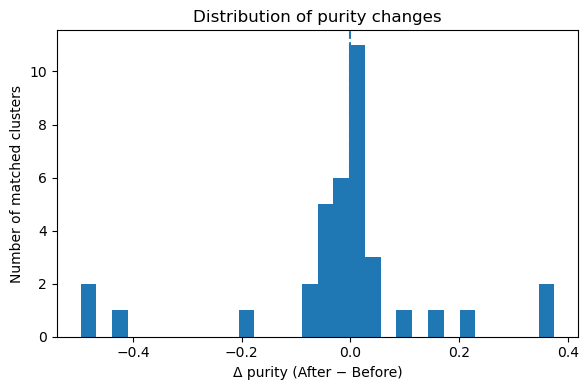

In [4]:
def cluster_purity_table(cluster_s: pd.Series, ctype_s: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({"cluster": cluster_s.astype(str), "ctype": ctype_s.astype(str)})

    ct = df.groupby(["cluster", "ctype"]).size().rename("count").reset_index()
    totals = ct.groupby("cluster")["count"].sum().rename("n_cells").reset_index()

    ct_sorted = ct.sort_values(["cluster", "count"], ascending=[True, False])
    top = (ct_sorted.groupby("cluster").head(1)
           .rename(columns={"ctype": "top_celltype", "count": "top_count"})[["cluster", "top_celltype", "top_count"]])

    n_types = ct.groupby("cluster")["ctype"].nunique().rename("n_celltypes").reset_index()

    ct2 = ct.merge(totals, on="cluster", how="left")
    ct2["p"] = ct2["count"] / ct2["n_cells"]
    ent = (ct2.assign(term=np.where(ct2["p"] > 0, -ct2["p"] * np.log2(ct2["p"]), 0.0))
              .groupby("cluster")["term"].sum().rename("entropy").reset_index())

    out = totals.merge(top, on="cluster").merge(n_types, on="cluster").merge(ent, on="cluster")
    out["purity"] = out["top_count"] / out["n_cells"]
    return out.sort_values(["purity", "n_cells"], ascending=[False, False]).reset_index(drop=True)

pur_before = cluster_purity_table(merged[f"{CLUSTER}_before"], merged[f"{CTYPE}_before"])
pur_after  = cluster_purity_table(merged[f"{CLUSTER}_after"],  merged[f"{CTYPE}_after"])

overall_before = pur_before["top_count"].sum() / pur_before["n_cells"].sum()
overall_after  = pur_after["top_count"].sum()  / pur_after["n_cells"].sum()

print("\nOverall weighted purity (matched cells only):")
print(f"  {LABEL_BEFORE} = {overall_before:.4f}")
print(f"  {LABEL_AFTER}  = {overall_after:.4f}")
print(f"  Diff (After - Before) = {(overall_after - overall_before):.4f}")


# -----------------------------
# Composition matrices (cluster x celltype fractions)
# -----------------------------
def composition_frac(cluster_s: pd.Series, ctype_s: pd.Series) -> pd.DataFrame:
    tab = pd.crosstab(cluster_s.astype(str), ctype_s.astype(str))
    frac = tab.div(tab.sum(axis=1), axis=0)
    return frac

frac_before = composition_frac(merged[f"{CLUSTER}_before"], merged[f"{CTYPE}_before"])
frac_after  = composition_frac(merged[f"{CLUSTER}_after"],  merged[f"{CTYPE}_after"])

# ensure same cell-type columns
all_types = sorted(set(frac_before.columns) | set(frac_after.columns))
frac_before = frac_before.reindex(columns=all_types, fill_value=0.0)
frac_after  = frac_after.reindex(columns=all_types, fill_value=0.0)

print("\nClusters BEFORE:", frac_before.shape[0], "| Clusters AFTER:", frac_after.shape[0], "| Cell types:", len(all_types))


# -----------------------------
# Match clusters using cosine similarity + Hungarian assignment
# -----------------------------
sim = cosine_similarity(frac_before.values, frac_after.values)      # (n_before x n_after)
cost = 1.0 - sim                                                   # Hungarian minimizes
row_ind, col_ind = linear_sum_assignment(cost)

match_df = pd.DataFrame({
    "cluster_before": frac_before.index[row_ind],
    "cluster_after":  frac_after.index[col_ind],
    "cosine_similarity": sim[row_ind, col_ind],
})

# attach purities
pur_before_map = pur_before.set_index("cluster")[["n_cells", "purity", "top_celltype"]].add_suffix("_before")
pur_after_map  = pur_after.set_index("cluster")[["n_cells", "purity", "top_celltype"]].add_suffix("_after")

match_df = (match_df
            .join(pur_before_map, on="cluster_before")
            .join(pur_after_map,  on="cluster_after"))

match_df["delta_purity_after_minus_before"] = match_df["purity_after"] - match_df["purity_before"]
match_df = match_df.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

print("\nMatched clusters:", len(match_df))
display(match_df.head(25))


# -----------------------------
# Simple paired statistical test on matched-cluster purities
# -----------------------------
paired = match_df.dropna(subset=["purity_before", "purity_after"]).copy()

# Wilcoxon signed-rank (simple, paired, nonparametric)
w_stat, w_p = wilcoxon(paired["purity_before"], paired["purity_after"])
print("\nPaired Wilcoxon signed-rank test on matched-cluster purity:")
print(f"  statistic = {w_stat:.3f}")
print(f"  p-value   = {w_p:.4e}")
print(f"  mean Δpurity (After − Before)   = {paired['delta_purity_after_minus_before'].mean():.4f}")
print(f"  median Δpurity (After − Before) = {paired['delta_purity_after_minus_before'].median():.4f}")

# (Optional) paired t-test (also simple)
t_stat, t_p = ttest_rel(paired["purity_after"], paired["purity_before"])
print("\nPaired t-test on matched-cluster purity:")
print(f"  t = {t_stat:.3f}")
print(f"  p = {t_p:.4e}")


# -----------------------------
# Nice figures (simple, clean)
# -----------------------------

# 1) Boxplot of matched-cluster purities
plt.figure(figsize=(6, 4))
plt.boxplot(
    [paired["purity_before"].values, paired["purity_after"].values],
    labels=[LABEL_BEFORE, LABEL_AFTER],
    showfliers=False
)
plt.ylim(0, 1)
plt.ylabel("Cluster purity (top celltype fraction)")
plt.title("Cluster purity across matched clusters")
plt.tight_layout()
plt.show()

# 2) Paired line plot (each line = one matched cluster)
plt.figure(figsize=(6, 4))
x0, x1 = 0, 1
for _, r in paired.iterrows():
    plt.plot([x0, x1], [r["purity_before"], r["purity_after"]], alpha=0.35)

# overlay means
plt.scatter([x0, x1], [paired["purity_before"].mean(), paired["purity_after"].mean()])
plt.xticks([x0, x1], [LABEL_BEFORE, LABEL_AFTER])
plt.ylim(0, 1)
plt.ylabel("Cluster purity (top celltype fraction)")
plt.title("Per-cluster purity change after REDSEA")
plt.tight_layout()
plt.show()

# 3) Histogram of purity differences (After - Before)
plt.figure(figsize=(6, 4))
plt.hist(paired["delta_purity_after_minus_before"].values, bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Δ purity (After − Before)")
plt.ylabel("Number of matched clusters")
plt.title("Distribution of purity changes")
plt.tight_layout()
plt.show()

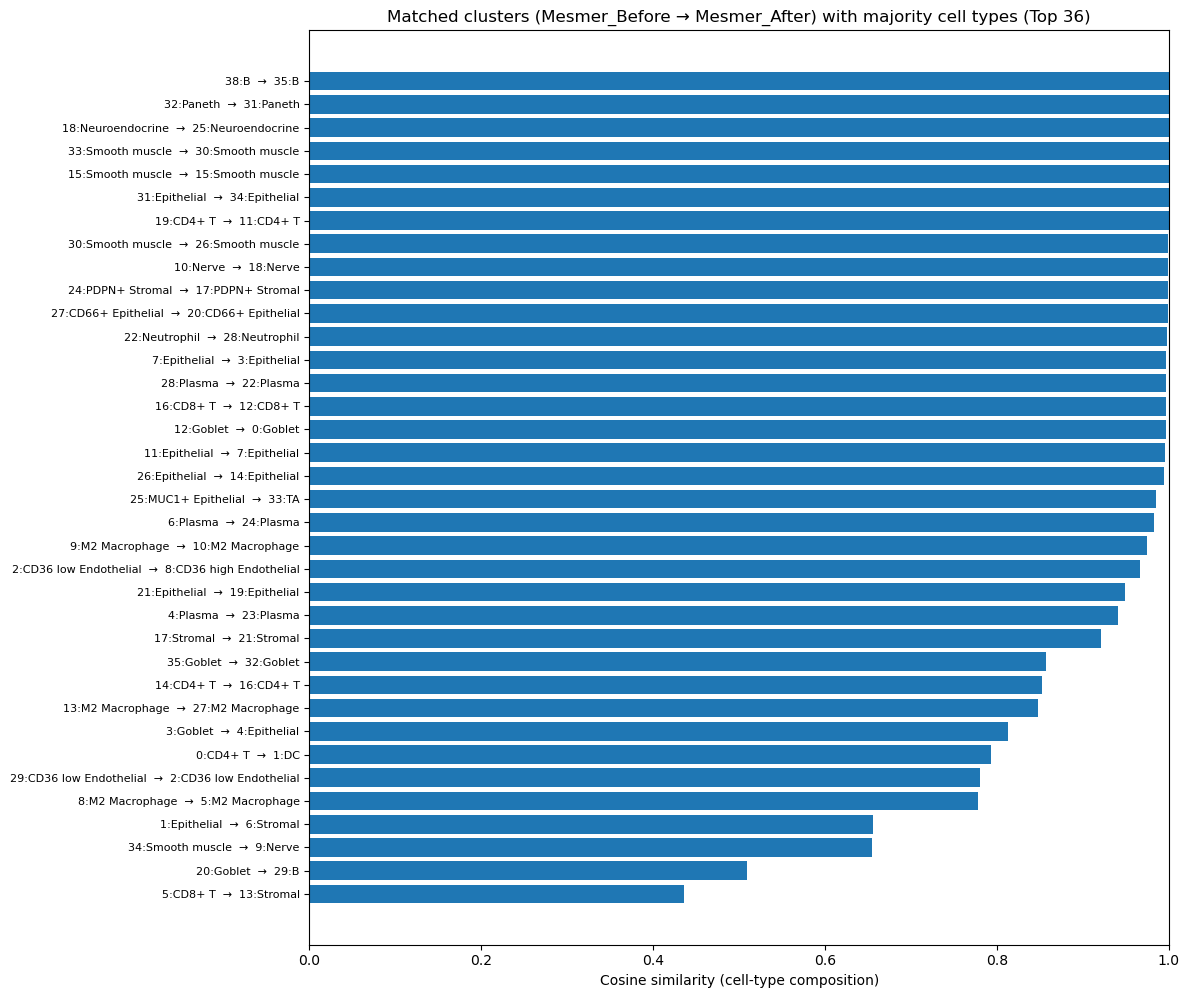

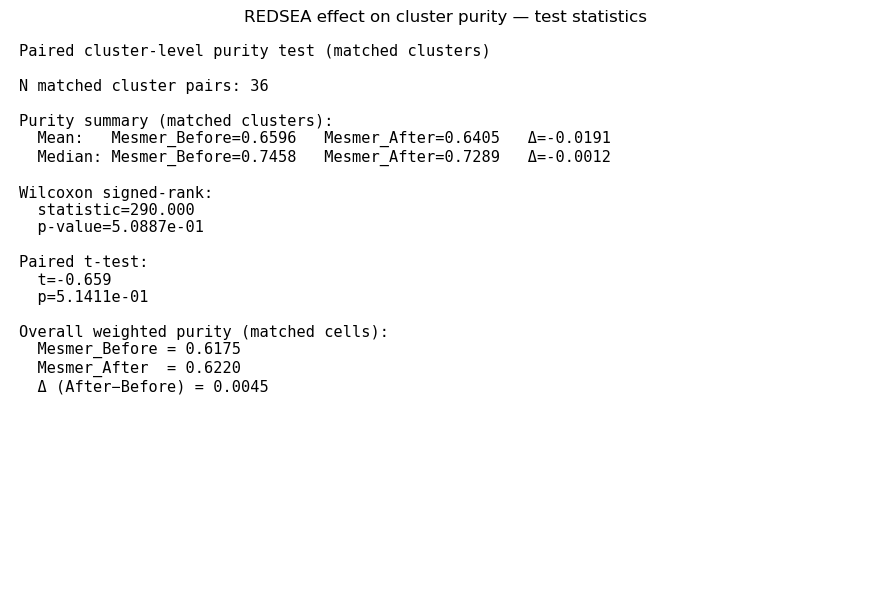

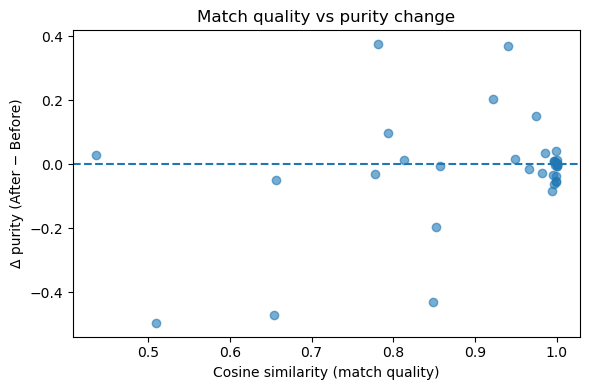

In [5]:


import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# 1) Bar chart of matched clusters (cosine similarity),
#    labeled by majority cell type in each matched cluster.
# -----------------------------
# Make a readable label per match: "<before_cluster>:<before_major>  →  <after_cluster>:<after_major>"
plot_matches = match_df.dropna(subset=["cosine_similarity", "top_celltype_before", "top_celltype_after"]).copy()

# If you have lots of clusters, show top-N by similarity for readability
TOP_N = min(40, len(plot_matches))
plot_matches = plot_matches.sort_values("cosine_similarity", ascending=False).head(TOP_N).copy()

plot_matches["match_label"] = (
    plot_matches["cluster_before"].astype(str) + ":" + plot_matches["top_celltype_before"].astype(str)
    + "  →  " +
    plot_matches["cluster_after"].astype(str) + ":" + plot_matches["top_celltype_after"].astype(str)
)

# Horizontal bar chart
plt.figure(figsize=(12, max(6, 0.28 * TOP_N)))
y = np.arange(len(plot_matches))
plt.barh(y, plot_matches["cosine_similarity"].values)
plt.yticks(y, plot_matches["match_label"].values, fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("Cosine similarity (cell-type composition)")
plt.title(f"Matched clusters ({LABEL_BEFORE} → {LABEL_AFTER}) with majority cell types (Top {TOP_N})")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


# -----------------------------
# 2) Figure showing test statistics (clean "stats panel")
# -----------------------------
# Effect sizes / summaries (simple, no extra inference)
mean_before  = float(paired["purity_before"].mean())
mean_after   = float(paired["purity_after"].mean())
med_before   = float(paired["purity_before"].median())
med_after    = float(paired["purity_after"].median())
mean_delta   = float((paired["purity_after"] - paired["purity_before"]).mean())
med_delta    = float((paired["purity_after"] - paired["purity_before"]).median())
n_pairs      = int(len(paired))

# Also show overall weighted purity (matched cells) if those vars exist
# (they do in your script: overall_before, overall_after)
try:
    w_overall_line = (
        f"Overall weighted purity (matched cells):\n"
        f"  {LABEL_BEFORE} = {overall_before:.4f}\n"
        f"  {LABEL_AFTER}  = {overall_after:.4f}\n"
        f"  Δ (After−Before) = {(overall_after - overall_before):.4f}\n"
    )
except NameError:
    w_overall_line = ""

stats_text = (
    f"Paired cluster-level purity test (matched clusters)\n\n"
    f"N matched cluster pairs: {n_pairs}\n\n"
    f"Purity summary (matched clusters):\n"
    f"  Mean:   {LABEL_BEFORE}={mean_before:.4f}   {LABEL_AFTER}={mean_after:.4f}   Δ={mean_delta:.4f}\n"
    f"  Median: {LABEL_BEFORE}={med_before:.4f}   {LABEL_AFTER}={med_after:.4f}   Δ={med_delta:.4f}\n\n"
    f"Wilcoxon signed-rank:\n"
    f"  statistic={w_stat:.3f}\n"
    f"  p-value={w_p:.4e}\n\n"
    f"Paired t-test:\n"
    f"  t={t_stat:.3f}\n"
    f"  p={t_p:.4e}\n\n"
    f"{w_overall_line}"
).strip()

plt.figure(figsize=(9, 6))
plt.axis("off")
plt.text(
    0.01, 0.99, stats_text,
    va="top", ha="left",
    family="monospace", fontsize=11
)
plt.title("REDSEA effect on cluster purity — test statistics", pad=12)
plt.tight_layout()
plt.show()


# -----------------------------
# 3) Optional: "volcano-like" view for interpretability
#    (similarity vs Δ purity) to spot unstable matches.
# -----------------------------
tmp = match_df.dropna(subset=["cosine_similarity", "purity_before", "purity_after"]).copy()
tmp["delta_purity"] = tmp["purity_after"] - tmp["purity_before"]

plt.figure(figsize=(6, 4))
plt.scatter(tmp["cosine_similarity"].values, tmp["delta_purity"].values, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Cosine similarity (match quality)")
plt.ylabel("Δ purity (After − Before)")
plt.title("Match quality vs purity change")
plt.tight_layout()
plt.show()


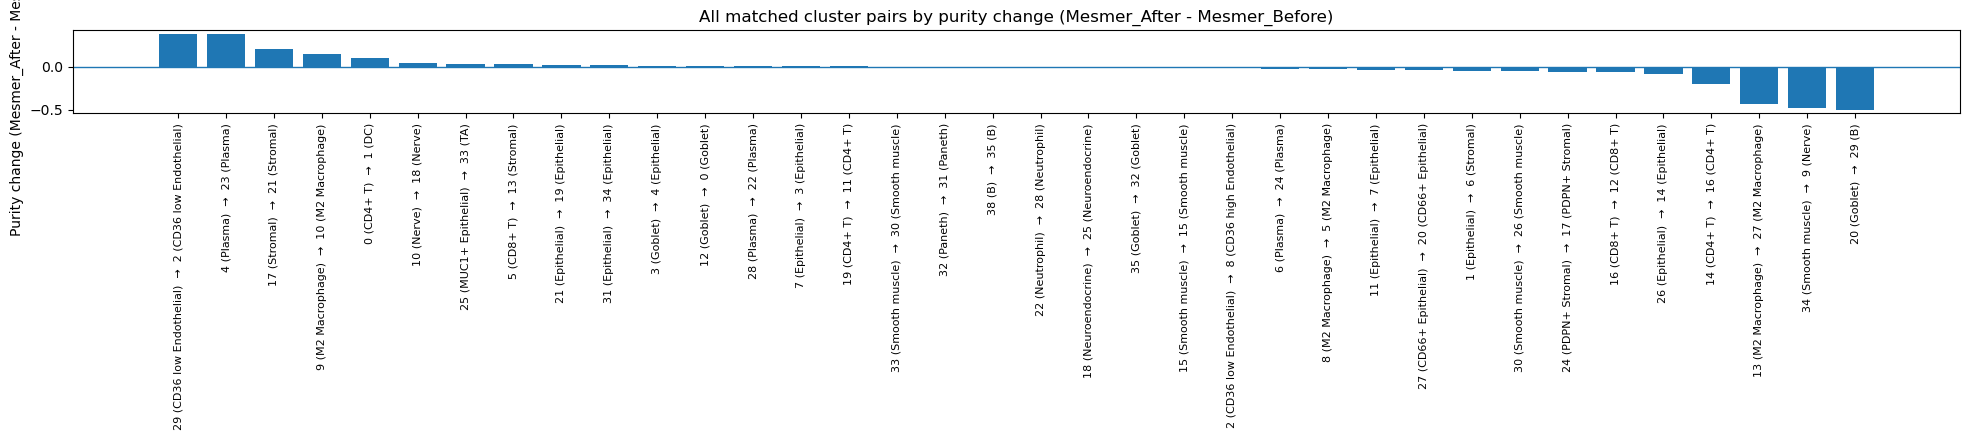

In [6]:

import numpy as np
import matplotlib.pyplot as plt

all_pairs = match_df.dropna(subset=[
    "cluster_before", "cluster_after",
    "top_celltype_before", "top_celltype_after",
    "purity_before", "purity_after"
]).copy()

all_pairs["delta_purity"] = all_pairs["purity_after"] - all_pairs["purity_before"]

# Label format like your example:
# "<before_cluster> (<before_major>) -> <after_cluster> (<after_major>)"
all_pairs["pair_label"] = (
    all_pairs["cluster_before"].astype(str) + " (" + all_pairs["top_celltype_before"].astype(str) + ")"
    + "  \u2192  " +
    all_pairs["cluster_after"].astype(str) + " (" + all_pairs["top_celltype_after"].astype(str) + ")"
)

# Sort by improvement (After - Before), descending
all_pairs = all_pairs.sort_values("delta_purity", ascending=False).reset_index(drop=True)

# --- Plot: ALL pairs ---
n = len(all_pairs)

# Dynamic sizing so labels remain readable (tune if needed)
fig_w = max(18, 0.55 * n)   # width grows with number of pairs
fig_h = 4.5                # keep height modest; labels are rotated

plt.figure(figsize=(fig_w, fig_h))
plt.bar(
    np.arange(n),
    all_pairs["delta_purity"].values
)
plt.axhline(0, linewidth=1)

plt.title(f"All matched cluster pairs by purity change ({LABEL_AFTER} - {LABEL_BEFORE})")
plt.ylabel(f"Purity change ({LABEL_AFTER} - {LABEL_BEFORE})")

plt.xticks(
    np.arange(n),
    all_pairs["pair_label"].values,
    rotation=90,
    ha="center",
    fontsize=8
)

plt.tight_layout()
plt.show()



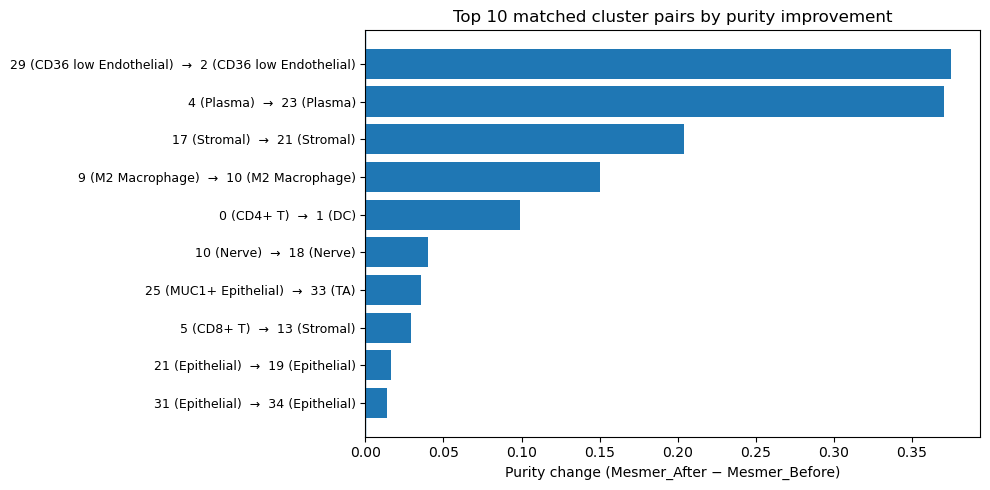

In [7]:
# ============================================================
# Top 10 matched cluster pairs by purity improvement (After - Before)
# Horizontal bar chart
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

top10 = match_df.dropna(subset=[
    "cluster_before", "cluster_after",
    "top_celltype_before", "top_celltype_after",
    "purity_before", "purity_after"
]).copy()

top10["delta_purity"] = top10["purity_after"] - top10["purity_before"]

# Sort by improvement and keep top 10
top10 = top10.sort_values("delta_purity", ascending=False).head(10)

# Label: "<before_cluster> (<before_major>) → <after_cluster> (<after_major>)"
top10["pair_label"] = (
    top10["cluster_before"].astype(str) + " (" + top10["top_celltype_before"].astype(str) + ")"
    + "  \u2192  " +
    top10["cluster_after"].astype(str) + " (" + top10["top_celltype_after"].astype(str) + ")"
)

# Reverse for horizontal bar plot (largest on top)
top10 = top10.iloc[::-1]

plt.figure(figsize=(10, 5))
plt.barh(
    np.arange(len(top10)),
    top10["delta_purity"].values
)

plt.yticks(
    np.arange(len(top10)),
    top10["pair_label"].values,
    fontsize=9
)

plt.axvline(0, linewidth=1)
plt.xlabel(f"Purity change ({LABEL_AFTER} − {LABEL_BEFORE})")
plt.title("Top 10 matched cluster pairs by purity improvement")
plt.tight_layout()
plt.show()


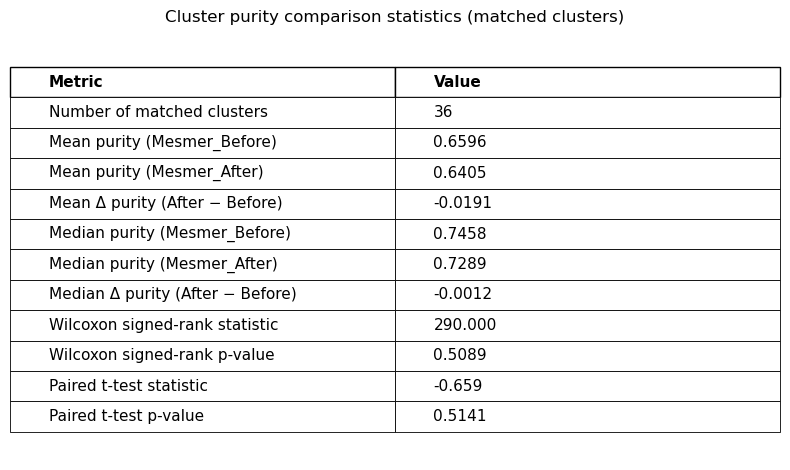

In [9]:
# ============================================================
# White, publication-style table (R-like)
# ============================================================

import matplotlib.pyplot as plt

table_rows = [
    ("Number of matched clusters", f"{len(paired)}"),
    (f"Mean purity ({LABEL_BEFORE})", f"{paired['purity_before'].mean():.4f}"),
    (f"Mean purity ({LABEL_AFTER})",  f"{paired['purity_after'].mean():.4f}"),
    ("Mean Δ purity (After − Before)", f"{(paired['purity_after'] - paired['purity_before']).mean():.4f}"),
    (f"Median purity ({LABEL_BEFORE})", f"{paired['purity_before'].median():.4f}"),
    (f"Median purity ({LABEL_AFTER})",  f"{paired['purity_after'].median():.4f}"),
    ("Median Δ purity (After − Before)", f"{(paired['purity_after'] - paired['purity_before']).median():.4f}"),
    ("Wilcoxon signed-rank statistic", f"{w_stat:.3f}"),
    ("Wilcoxon signed-rank p-value",   f"{w_p:.4f}"),
    ("Paired t-test statistic",        f"{t_stat:.3f}"),
    ("Paired t-test p-value",          f"{t_p:.4f}")
]

# Build figure
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.axis("off")

# Create table
tbl = ax.table(
    cellText=table_rows,
    colLabels=["Metric", "Value"],
    colLoc="left",
    cellLoc="left",
    loc="center"
)

# Style table to look like R output
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.6)
    cell.set_facecolor("white")
    if row == 0:  # header
        cell.set_text_props(weight="bold")
        cell.set_linewidth(1.0)

plt.title("Cluster purity comparison statistics (matched clusters)", pad=12)
plt.tight_layout()
plt.show()

